Импорт необходимых модулей:

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

Запускаем сценарий сборки

In [2]:
os.system("make")

g++ -c -Wall -O3 -DNDEBUG -o release/main.o main.cpp
g++ -c -Wall -O3 -DNDEBUG -o release/xor_shift_64__generator_class.o xor_shift_64__generator_class.cpp
g++ -c -Wall -O3 -DNDEBUG -o release/xor_shift_1024__generator_class.o xor_shift_1024__generator_class.cpp
g++ -c -Wall -O3 -DNDEBUG -o release/mt19937__sample_class.o mt19937__sample_class.cpp
g++ -c -Wall -O3 -DNDEBUG -o release/xor_shift_64__sample_class.o xor_shift_64__sample_class.cpp
g++ -c -Wall -O3 -DNDEBUG -o release/xor_shift_1024__sample_class.o xor_shift_1024__sample_class.cpp
g++ -Wall -O3 -DNDEBUG -o release/executable release/main.o release/xor_shift_64__generator_class.o release/xor_shift_1024__generator_class.o release/mt19937__sample_class.o release/xor_shift_64__sample_class.o release/xor_shift_1024__sample_class.o


0

Запускаем генерацию точек

In [3]:
os.system("release/executable --xs64 10000000 0 1")
os.system("release/executable --xs1024 10000000 0 1")
os.system("release/executable --mt19937 10000000 0 1")

0

Подгружаем сгенерированные выборки:

In [4]:
x64      = pd.read_csv("xor_shift_64__sample.csv")
x1024    = pd.read_csv("xor_shift_1024__sample.csv")
mt19937  = pd.read_csv("mt19937__sample.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [5]:
x64.head()

,randoms
0,0.106121
1,0.867239
2,0.537790
3,0.504796
4,0.691059


Описательная статистика:

In [6]:
x64['randoms'].describe()

count    1.000000e+07
mean     4.999790e-01
std      2.887010e-01
min      2.116430e-08
25%      2.501230e-01
50%      4.998590e-01
75%      7.500140e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

(99000.0, 101500.0)

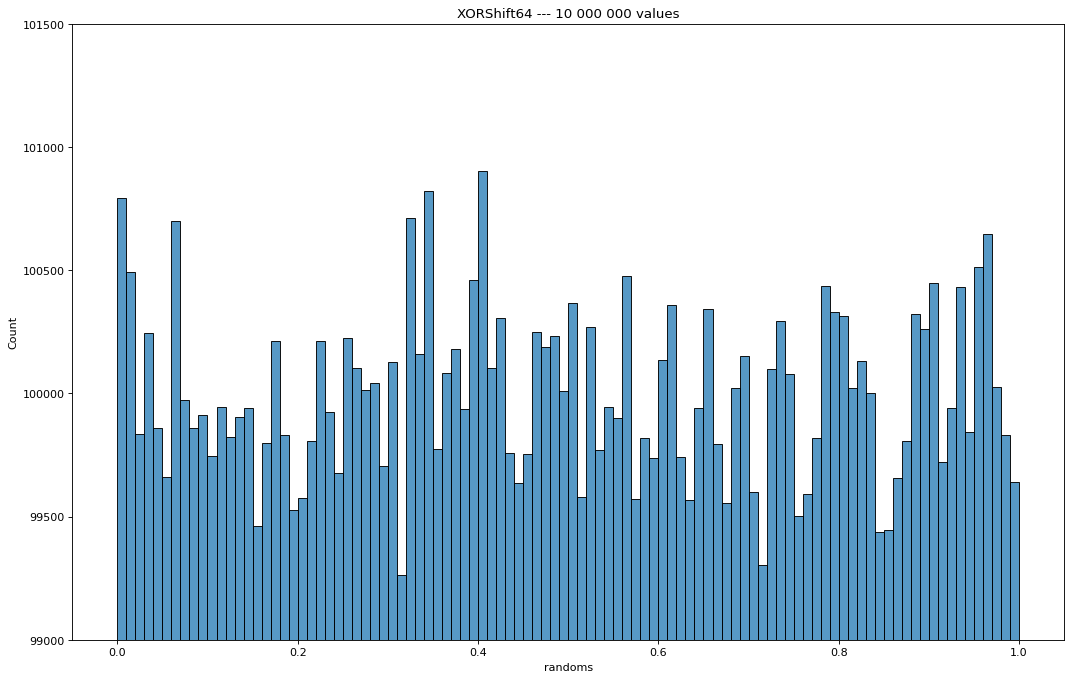

In [7]:
plt.figure(figsize=(16, 10), dpi=80)
sns.histplot(data=x64, x="randoms", bins=100).set(title='XORShift64 --- 10 000 000 values')
plt.ylim(bottom=99000, top=101500)

(99000.0, 101500.0)

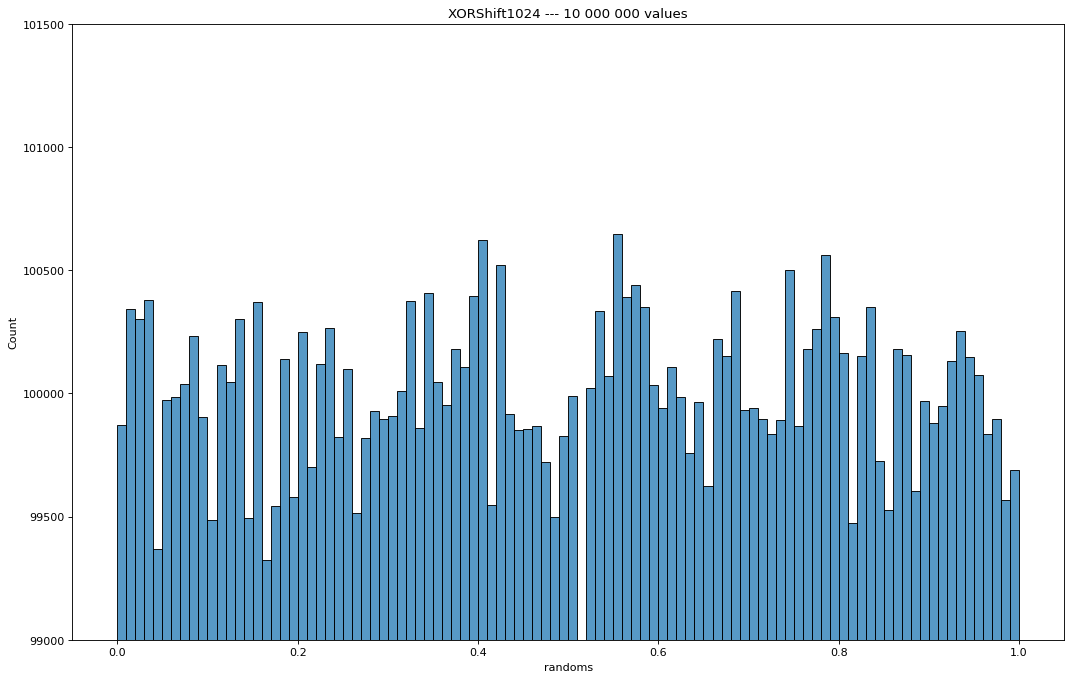

In [8]:
plt.figure(figsize=(16, 10), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=100).set(title='XORShift1024 --- 10 000 000 values')
plt.ylim(bottom=99000, top=101500)

(99000.0, 101500.0)

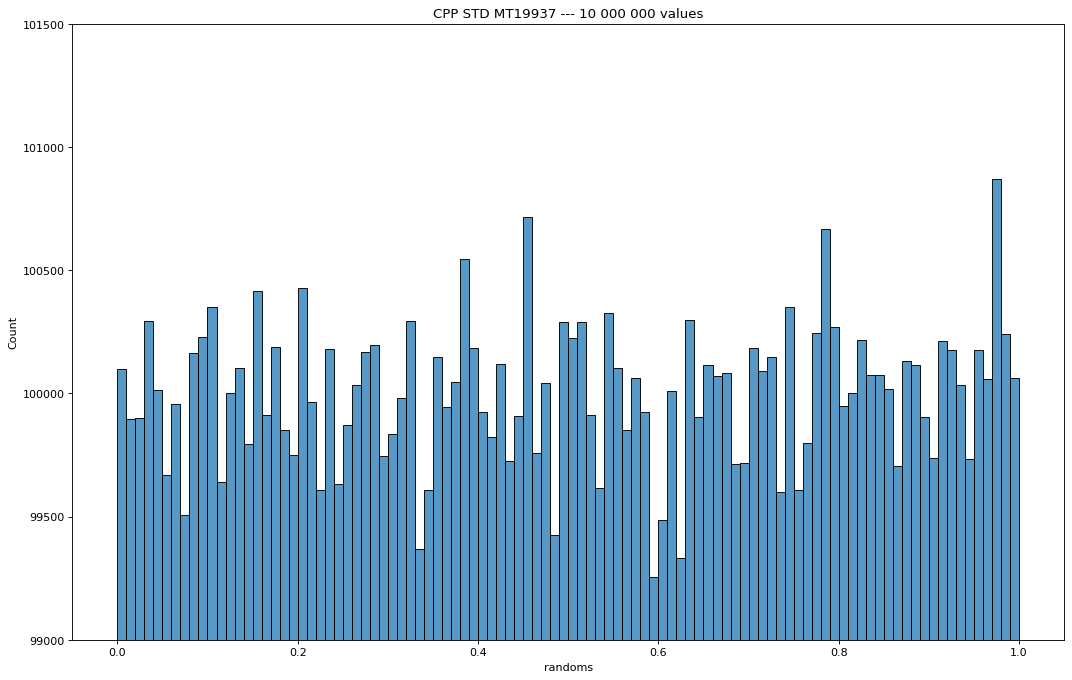

In [9]:
plt.figure(figsize=(16, 10), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=100).set(title='CPP STD MT19937 --- 10 000 000 values')
plt.ylim(bottom=99000, top=101500)